✅ Đã tìm thấy gốc dự án tại: D:\YELLOWTAXI-NYC2021
📁 Tệp có tồn tại không?: True
🚀 Tải thành công! Kích thước dữ liệu: (45300, 9)
Đang tiến hành tính toán các chỉ số tối ưu (Quá trình này có thể mất 1-2 phút)...
➔ K = 2 | Inertia: 59990.66 | Silhouette: 0.6829 | DB Index: 0.7324
➔ K = 3 | Inertia: 43200.77 | Silhouette: 0.4992 | DB Index: 0.7340
➔ K = 4 | Inertia: 36167.31 | Silhouette: 0.4972 | DB Index: 0.9567
➔ K = 5 | Inertia: 31162.18 | Silhouette: 0.3235 | DB Index: 1.1372
➔ K = 6 | Inertia: 27712.92 | Silhouette: 0.3320 | DB Index: 1.0175


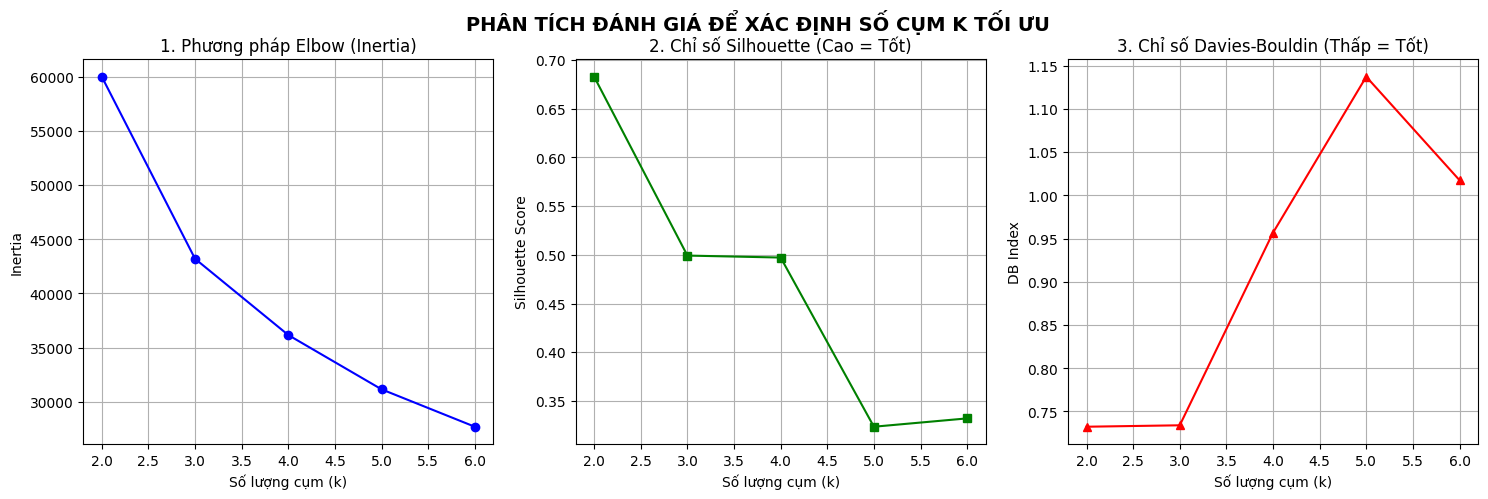


--- Tiến hành phân cụm động với K = 3 ---
✅ ĐÃ XUẤT FILE ĐẦU RA CHO NHÓM: d:\YELLOWTAXI-NYC2021\Data\processed\advanced_pattern\dynamic_zone_clusters.parquet

Thống kê số lượng trạng thái lọt vào từng cụm:
cluster
0    17104
1     1896
2     3149
Name: count, dtype: int64

[KIỂM TRA CHÉO] Sự thay đổi nhãn cụm theo giờ của Zone 141:
       pickup_hour  day_of_week  cluster
22516            0            0        0
22517            0            0        0
22518            0            1        0
22519            0            2        0
22520            0            3        0
22521            0            3        0
22522            0            4        0
22523            0            4        0
22524            0            5        0
22525            0            5        0


In [7]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# THÊM MỚI: Chỉ số đánh giá nâng cao theo yêu cầu
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Đi ngược lên trên cho đến khi tìm thấy thư mục "Data"
root = Path(os.getcwd())
while not (root / "Data").exists() and root.parent != root:
    root = root.parent

# Bây giờ đường dẫn sẽ luôn đúng dù bạn chạy ở bất kỳ máy nào, tệp nào
DATA_PROCESSED = root / "Data" / "processed"
file_features = DATA_PROCESSED / "df_time_features.parquet"

print(f"✅ Đã tìm thấy gốc dự án tại: {root.resolve()}")
print(f"📁 Tệp có tồn tại không?: {file_features.exists()}")

# Đọc file luôn tại đây
df_time = pd.read_parquet(file_features)
print(f"🚀 Tải thành công! Kích thước dữ liệu: {df_time.shape}")

# Lọc bớt các bản ghi quá ít chuyến để tránh nhiễu mô hình
df_time = df_time[df_time["total_trips"] > 10].copy()

# --- 2. CHUẨN HÓA CÁC ĐẶC TRƯNG ĐỘNG ---
# Các biến dùng để định hình trạng thái giao thông tại khung giờ đó
features_to_cluster = ["total_trips", "avg_revenue", "median_speed", "avg_duration", "avg_distance"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_time[features_to_cluster])

# --- 3. ĐÁNH GIÁ TÌM K TỐI ƯU BẰNG 3 CHỈ SỐ (ELBOW, SILHOUETTE, DB INDEX) ---
K_range = range(2, 7) # Thử nghiệm từ 2 đến 6 cụm (Silhouette không chạy được với k=1)
inertia = []
silhouette_vals = []
db_scores = []

print("Đang tiến hành tính toán các chỉ số tối ưu (Quá trình này có thể mất 1-2 phút)...")

# Lấy mẫu ngẫu nhiên khoảng 20,000 dòng để tính Silhouette nhanh hơn (vì ma trận lớn tính toàn bộ sẽ rất lâu)
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=min(20000, X_scaled.shape[0]), replace=False)
X_scaled_sample = X_scaled[sample_idx]

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    # 1. Chỉ số Inertia (Elbow)
    inertia.append(model.inertia_)
    
    # 2. Chỉ số Silhouette (Càng gần 1 càng tốt)
    sil = silhouette_score(X_scaled_sample, labels[sample_idx])
    silhouette_vals.append(sil)
    
    # 3. Chỉ số Davies-Bouldin (Càng nhỏ càng tốt)
    db = davies_bouldin_score(X_scaled, labels)
    db_scores.append(db)
    print(f"➔ K = {k} | Inertia: {model.inertia_:.2f} | Silhouette: {sil:.4f} | DB Index: {db:.4f}")

# --- 4. VẼ BIỂU ĐỒ SO SÁNH ĐA CHỈ SỐ ĐỂ ĐƯA VÀO BÁO CÁO ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Đồ thị Elbow
axs[0].plot(K_range, inertia, marker="o", color="blue")
axs[0].set_title("1. Phương pháp Elbow (Inertia)")
axs[0].set_xlabel("Số lượng cụm (k)")
axs[0].set_ylabel("Inertia")
axs[0].grid(True)

# Đồ thị Silhouette
axs[1].plot(K_range, silhouette_vals, marker="s", color="green")
axs[1].set_title("2. Chỉ số Silhouette (Cao = Tốt)")
axs[1].set_xlabel("Số lượng cụm (k)")
axs[1].set_ylabel("Silhouette Score")
axs[1].grid(True)

# Đồ thị Davies-Bouldin
axs[2].plot(K_range, db_scores, marker="^", color="red")
axs[2].set_title("3. Chỉ số Davies-Bouldin (Thấp = Tốt)")
axs[2].set_xlabel("Số lượng cụm (k)")
axs[2].set_ylabel("DB Index")
axs[2].grid(True)

plt.suptitle("PHÂN TÍCH ĐÁNH GIÁ ĐỂ XÁC ĐỊNH SỐ CỤM K TỐI ƯU", fontsize=14, fontweight='bold')
plt.savefig(FIGURES / "advanced_metrics_evaluation.png", bbox_inches="tight")
plt.show()

# --- 5. ÁP DỤNG K-MEANS ĐỘNG VỚI K TỐI ƯU (VÍ DỤ CHỌN K=3) ---
best_k = 3
print(f"\n--- Tiến hành phân cụm động với K = {best_k} ---")
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_time["cluster"] = final_kmeans.fit_predict(X_scaled)

# Lưu tệp kết quả phân cụm ĐỘNG bàn giao cho Thành viên 3 (Vẽ GIS) và Thành viên 4 (Học máy)
output_path = DATA_PROCESSED / "advanced_pattern/dynamic_zone_clusters.parquet"
df_time.to_parquet(output_path, index=False)
print(f"✅ ĐÃ XUẤT FILE ĐẦU RA CHO NHÓM: {output_path}")

# Thống kê kết quả phân cụm
print("\nThống kê số lượng trạng thái lọt vào từng cụm:")
print(df_time["cluster"].value_counts().sort_index())

# In thử nghiệm kiểm tra tính "ĐỘNG" của 1 Zone bất kỳ (Ví dụ Zone 141)
print("\n[KIỂM TRA CHÉO] Sự thay đổi nhãn cụm theo giờ của Zone 141:")
print(df_time[df_time["PULocationID"] == 141][["pickup_hour", "day_of_week", "cluster"]].head(10))


--- ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM TRẠNG THÁI ĐỘNG ---


,total_trips,avg_revenue,median_speed,avg_duration,avg_distance,count_state_records
cluster,,,,,,
0,409.56,19.209999,13.890000,13.45,3.41,17104
1,909.69,54.650002,25.120001,32.34,12.33,1896
2,6143.75,16.320000,10.430000,12.08,2.24,3149


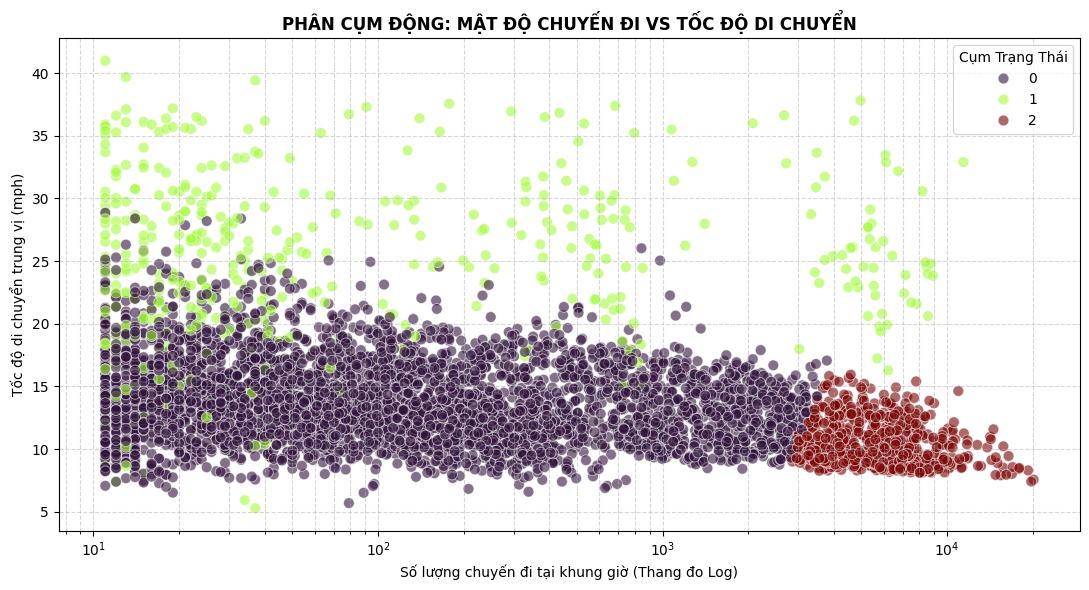

In [9]:
# --- 5. INTERPRETATION & VISUALIZATION (PHÂN CỤM ĐỘNG) ---
# Thống kê đặc trưng trung bình của từng Cụm trạng thái
dynamic_features = ["total_trips", "avg_revenue", "median_speed", "avg_duration", "avg_distance"]

cluster_summary = (
    df_time
    .groupby("cluster")[dynamic_features]
    .mean()
    .round(2)
)
cluster_summary["count_state_records"] = df_time["cluster"].value_counts()
print("\n--- ĐẶC ĐIỂM TRUNG BÌNH CỦA TỪNG CỤM TRẠNG THÁI ĐỘNG ---")
display(cluster_summary)

# Biểu đồ Scatter phân tích mối quan hệ: Mật độ chuyến đi vs Tốc độ di chuyển
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df_time.sample(n=min(5000, len(df_time)), random_state=42), # Lấy mẫu để biểu đồ mượt, không bị nghẽn nét vẽ
    x="total_trips",
    y="median_speed",
    hue="cluster",
    palette="turbo",
    s=60,
    alpha=0.6
)
plt.xscale("log")
plt.title("PHÂN CỤM ĐỘNG: MẬT ĐỘ CHUYẾN ĐI VS TỐC ĐỘ DI CHUYỂN", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng chuyến đi tại khung giờ (Thang đo Log)")
plt.ylabel("Tốc độ di chuyển trung vị (mph)")
plt.legend(title="Cụm Trạng Thái")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES / "dynamic_cluster_scatter.png", dpi=300)
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_25728\921088470.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_25728\921088470.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_25728\921088470.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


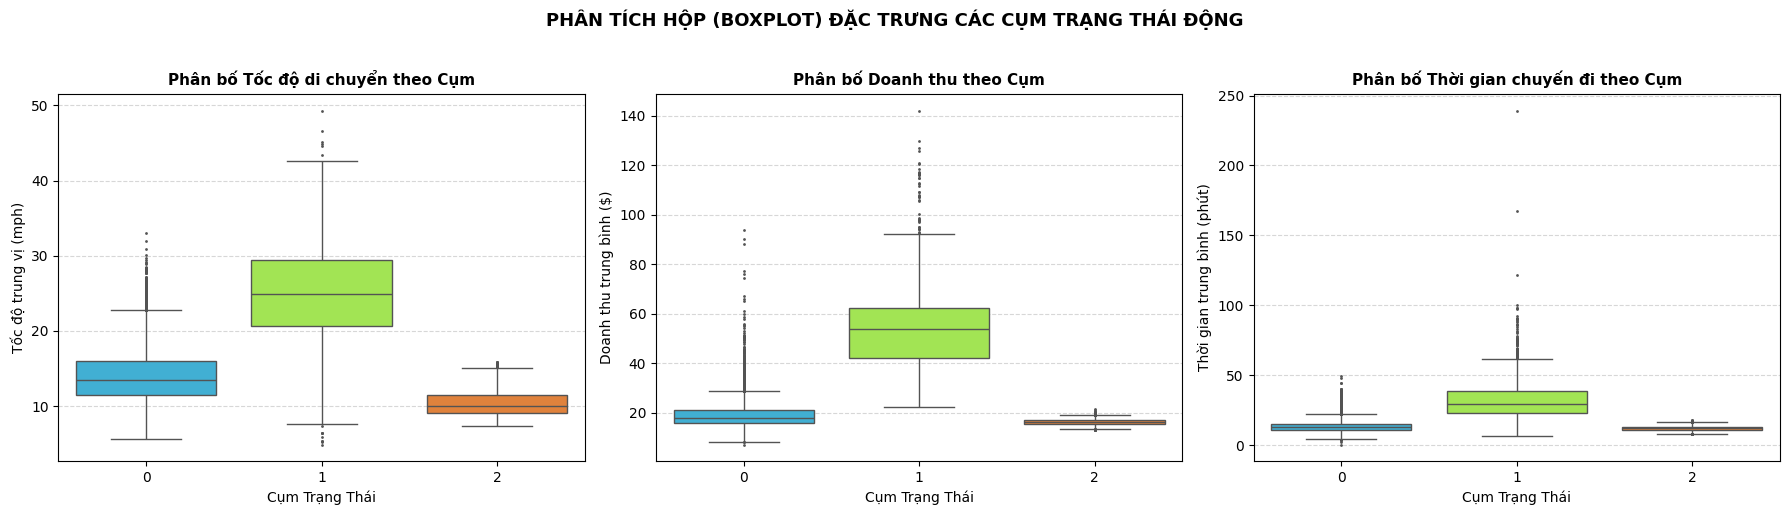

In [10]:
# --- 6. ADVANCED VISUALIZATION: BOXPLOTS (NÂNG CẤP ĐỘNG) ---
# Mục tiêu: So sánh phân bố các chỉ số lõi giữa các cụm trạng thái không - thời gian

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot 1: Phân bố Tốc độ di chuyển trung vị (Biến lõi của bài toán động)
sns.boxplot(
    data=df_time,
    x="cluster",
    y="median_speed",
    palette="turbo",  # Đồng bộ hệ màu với biểu đồ Scatter động
    ax=axes[0],
    fliersize=1       # Thu nhỏ kích thước các điểm ngoại lai (outliers) để đồ thị gọn gàng hơn
)
axes[0].set_title("Phân bố Tốc độ di chuyển theo Cụm", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Cụm Trạng Thái")
axes[0].set_ylabel("Tốc độ trung vị (mph)")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Boxplot 2: Phân bố Doanh thu trung bình thu được tại khung giờ
sns.boxplot(
    data=df_time,
    x="cluster",
    y="avg_revenue",
    palette="turbo",
    ax=axes[1],
    fliersize=1
)
axes[1].set_title("Phân bố Doanh thu theo Cụm", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Cụm Trạng Thái")
axes[1].set_ylabel("Doanh thu trung bình ($)")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Boxplot 3: Phân bố Thời gian di chuyển trung bình của chuyến đi
sns.boxplot(
    data=df_time,
    x="cluster",
    y="avg_duration",
    palette="turbo",
    ax=axes[2],
    fliersize=1
)
axes[2].set_title("Phân bố Thời gian chuyến đi theo Cụm", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Cụm Trạng Thái")
axes[2].set_ylabel("Thời gian trung bình (phút)")
axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa hiển thị tổng thể và lưu file ảnh sạch (đã sửa lỗi lặp thư mục)
plt.suptitle("PHÂN TÍCH HỘP (BOXPLOT) ĐẶC TRƯNG CÁC CỤM TRẠNG THÁI ĐỘNG", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "dynamic_cluster_boxplots.png", dpi=300)
plt.show()

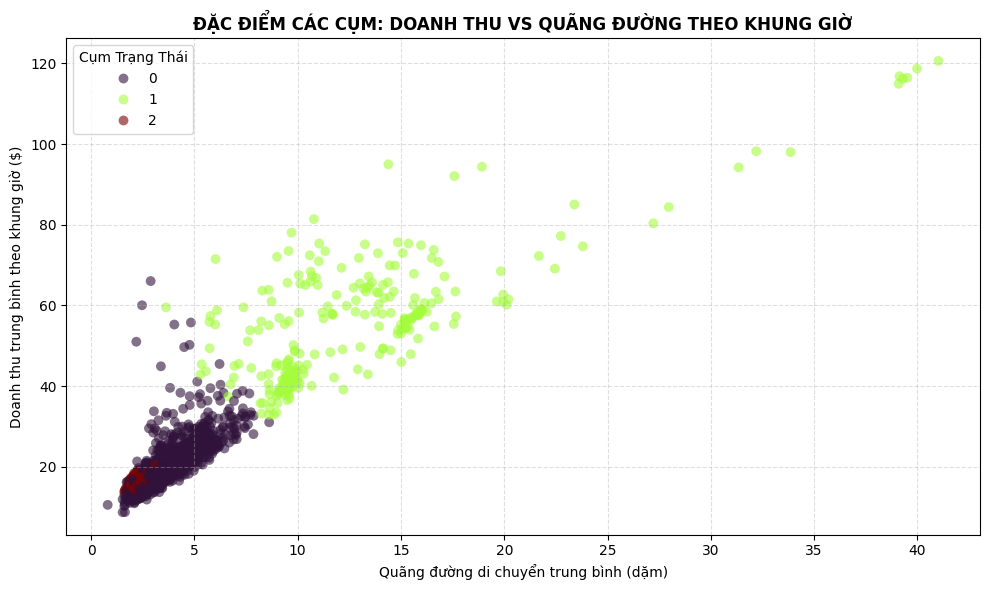

In [13]:
# --- 7. ECONOMIC VIEW: REVENUE VS DISTANCE (NÂNG CẤP ĐỘNG) ---
# Mục tiêu: Phân tích hiệu suất kinh tế (Doanh thu tương quan với Quãng đường di chuyển)

plt.figure(figsize=(10, 6))

# Lấy mẫu ngẫu nhiên khoảng 3000 điểm để biểu đồ không bị quá dày đặc và chồng chéo màu
df_econ_visual = df_time.sample(n=min(3000, len(df_time)), random_state=42)

sns.scatterplot(
    data=df_econ_visual,
    x="avg_distance",
    y="avg_revenue",
    hue="cluster",
    palette="turbo",  # Giữ đồng bộ hệ màu turbo với Scatter và Boxplot trước đó
    s=50,
    alpha=0.6,
    edgecolor='none'  # Bỏ viền để các hạt nhìn mượt và rõ cụm hơn
)

plt.title("ĐẶC ĐIỂM CÁC CỤM: DOANH THU VS QUÃNG ĐƯỜNG THEO KHUNG GIỜ", fontsize=12, fontweight='bold')
plt.xlabel("Quãng đường di chuyển trung bình (dặm)")
plt.ylabel("Doanh thu trung bình theo khung giờ ($)")
plt.legend(title="Cụm Trạng Thái")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Lưu file trực tiếp vào thư mục figures (đã bỏ advanced_pattern/ bị lặp gây lỗi)
plt.savefig(FIGURES / "dynamic_fare_vs_distance.png", dpi=300)
plt.show()